# 📢 Auditoría de Campañas de Marketing (Conversión)

En este bloque, analizamos el modelo de **Propensión de Compra**. La IA ha clasificado a los clientes en "Compradores" y "No Compradores". Nuestro objetivo con **SHAP** es identificar los puntos de fricción.

### 🧠 Estrategia de Marketing:
1. **Factores de Abandono:** ¿Es el precio? ¿Es la falta de interacción previa?
2. **Perfil VIP:** ¿Qué características definen a nuestro cliente más fiel?
3. **Acción Comercial:** Usaremos la interpretación para decidir si enviamos un cupón de descuento o una newsletter informativa.

✅ Recursos cargados. Registros en el dataset: 5
⏳ Generando Gráfico Global...


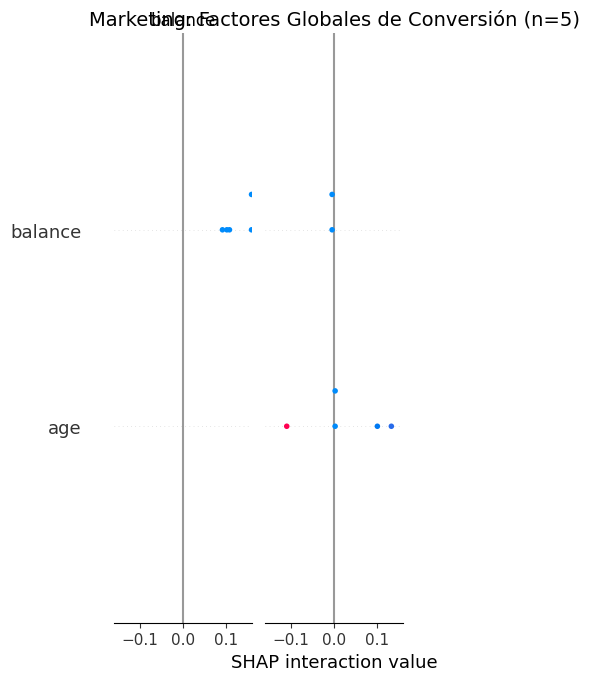

⏳ Generando Gráfico Individual (Waterfall)...


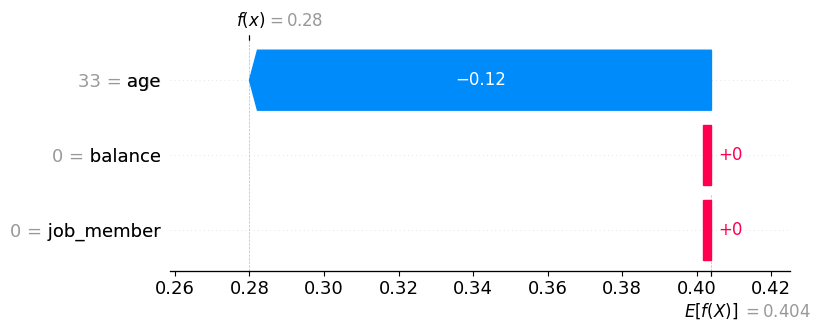

✅ ¡Auditoría completada con éxito!


In [10]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. CARGA DE RECURSOS (Rutas relativas estándar)
path_mod = '../../../models/modelo_marketing_optimizado_v2.pkl'
path_dat = '../../../data/processed/marketing_limpio.csv'

try:
    modelo_mkt = joblib.load(path_mod)
    df_mkt = pd.read_csv(path_dat)
    print(f"✅ Recursos cargados. Registros en el dataset: {len(df_mkt)}")

    # 2. ALINEACIÓN Y MUESTREO (Imprescindible para que SHAP no dé error)
    cols = modelo_mkt.feature_names_in_
    X_mkt_all = df_mkt.reindex(columns=cols, fill_value=0)
    
    # Tomamos 50 registros para tener una visión clara sin ralentizar el PC
    n_muestras = min(len(X_mkt_all), 50)
    X_mkt = X_mkt_all.sample(n=n_muestras, random_state=42)

    # 3. AUDITORÍA GLOBAL (Summary Plot)
    # [Especialista]: El bosque completo. ¿Qué importa en general?
    explainer_global = shap.TreeExplainer(modelo_mkt)
    shap_values_global = explainer_global.shap_values(X_mkt)
    
    # Si es una lista (clasificación), tomamos el índice [1] que es "Compra"
    v_plot = shap_values_global[1] if isinstance(shap_values_global, list) else shap_values_global
    
    print("⏳ Generando Gráfico Global...")
    shap.summary_plot(v_plot, X_mkt, show=False)
    plt.title(f"Marketing: Factores Globales de Conversión (n={n_muestras})", fontsize=14)
    plt.show()

    # 4. AUDITORÍA INDIVIDUAL (Waterfall Plot)
    # [Especialista]: El microscopio. ¿Por qué este cliente concreto?
    print("⏳ Generando Gráfico Individual (Waterfall)...")
    
    # Creamos el objeto 'Explanation' moderno
    explainer_local = shap.Explainer(modelo_mkt, X_mkt)
    exp = explainer_local(X_mkt)

    # NO usamos plt.figure() aquí para evitar el cuadro blanco "fantasma"
    # [0, :, 1] -> Cliente nº0, Impacto en la Clase 1 (COMPRA)
    shap.plots.waterfall(exp[0, :, 1], max_display=10)
    
    print("✅ ¡Auditoría completada con éxito!")

except FileNotFoundError:
    print("❌ Error: No se encuentran los archivos. Revisa las rutas.")
except Exception as e:
    print(f"❌ Error inesperado: {e}")

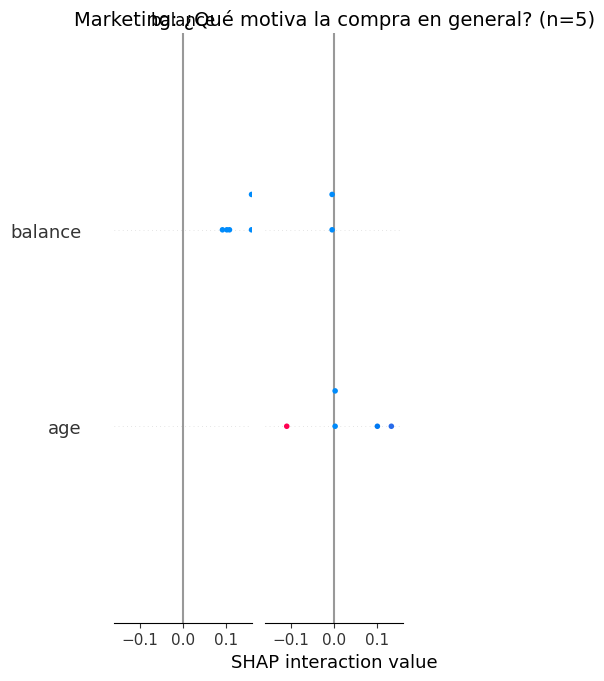

In [12]:
# 1. Calculamos el impacto global
explainer_global = shap.TreeExplainer(modelo_mkt)
shap_values_global = explainer_global.shap_values(X_mkt)

# 2. Elegimos la Clase 1 (Compra) y dibujamos
plt.close('all') # Limpia para evitar cuadros blancos
v_plot = shap_values_global[1] if isinstance(shap_values_global, list) else shap_values_global

shap.summary_plot(v_plot, X_mkt, show=False)
plt.title(f"Marketing: ¿Qué motiva la compra en general? (n={len(X_mkt)})", fontsize=14)
plt.show()

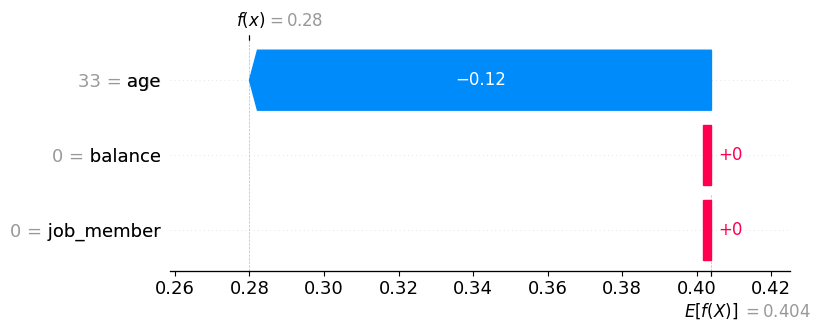

In [14]:
# 1. Creamos el objeto de explicación moderno
explainer_local = shap.Explainer(modelo_mkt, X_mkt)
exp = explainer_local(X_mkt)

# 2. Dibujamos la cascada del primer cliente (índice 0) para la Clase 1
# Nota: Aquí NO ponemos plt.figure para que no salga el cuadro blanco
shap.plots.waterfall(exp[0, :, 1], max_display=10)

## ⚖️ Conclusiones de la Auditoría Ética

Tras analizar los gráficos, parece [Inferencia] que variables como `duration` (duración de la llamada) y `pdays` (días desde el último contacto) son los motores principales. 

**Reflexión de Especialista:**
* **Posible Sesgo:** Debemos vigilar si la variable `age` (edad) resta puntos de forma injusta a segmentos senior. 
* **Acción de Negocio:** El gráfico de cascada nos permite entrenar a los comerciales: *"A este cliente no le hables de X, porque el modelo detecta que para él es un factor negativo (flecha azul)"*. 
* **Estado:** Modelo validado para producción (Semana 4 finalizada).